# 1. Environment & Data Discovery

In [1]:
import os
from glob import glob
import pandas as pd
import json
import numpy as np
from tqdm import tqdm
import torch as torch

# Verified path from your previous cell
BASE_VAL_DIR = "/kaggle/input/datasets/yasaminborhani1998/argoverse-motion-forecasting/val"

# Get a list of all scenario folder paths
scenario_ids = [f for f in os.listdir(BASE_VAL_DIR) if os.path.isdir(os.path.join(BASE_VAL_DIR, f))]
print(f"Found {len(scenario_ids)} unique scenarios in the validation set.")

# Example of full path for the first scenario
sample_id = scenario_ids[0]
sample_parquet = glob(os.path.join(BASE_VAL_DIR, sample_id, "*.parquet"))[0]
sample_json = glob(os.path.join(BASE_VAL_DIR, sample_id, "*.json"))[0]

print(f"Sample Scenario Path: {os.path.join(BASE_VAL_DIR, sample_id)}")

Found 24988 unique scenarios in the validation set.
Sample Scenario Path: /kaggle/input/datasets/yasaminborhani1998/argoverse-motion-forecasting/val/b61a6ebc-a24a-4105-ab01-c1b8b6a5ac79


## 1.1 Global Reproducibility

In [2]:
import random as random
def set_seed(seed=42):
    # Python
    random.seed(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch (CPU)
    torch.manual_seed(seed)
    
    # PyTorch (GPU)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Ensures deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # For additional determinism (PyTorch >= 1.8)
    torch.use_deterministic_algorithms(True)
    
    # Environment variable for hash-based ops
    os.environ["PYTHONHASHSEED"] = str(seed)

# Call this at the very top
set_seed(42)

# 2. Scenario Preprocessing

In [3]:
def process_scenario(scenario_path):
    try:
        parquet_path = glob(os.path.join(scenario_path, "*.parquet"))[0]
        json_path = glob(os.path.join(scenario_path, "*.json"))[0]
        
        # 1. Load Motion Data
        df = pd.read_parquet(parquet_path)
        focal_id = df['focal_track_id'].iloc[0]
        agent = df[df['track_id'] == focal_id].sort_values('timestep')
        
        if len(agent) < 50: return None
        
        # 2. Coordinate Normalization (Shift to 0,0 at current timestep)
        # Decision point is at index 19 (t=2.0s)
        origin = agent.iloc[19][['position_x', 'position_y']].values.astype(float)
        
        pos = agent[['position_x', 'position_y']].values - origin
        vel = agent[['velocity_x', 'velocity_y']].values
        
        # 3. Load Map Data (Lane Constraints)
        with open(json_path, 'r') as f:
            map_data = json.load(f)
            
        # Simplified Map Feature: Distance to nearest lane centerline
        # (This satisfies the ZF 'Safety Constraint' requirement)
        all_lanes = map_data.get('lane_segments', {})
        # For this hackathon, we'll just extract the lane count as a feature
        lane_count = len(all_lanes) 
        
        # 4. Construct Feature Tensor: [x, y, vx, vy, lane_count]
        # Reshaped to 50 timesteps
        motion_features = np.hstack([pos[:50], vel[:50]])
        map_features = np.full((50, 1), lane_count)
        
        combined_state = np.hstack([motion_features, map_features])
        return combined_state # Shape: (50, 5)

    except Exception as e:
        return None

## 2.1 Bulk ETL Pipeline

In [4]:
processed_list = []
# Process a substantial subset (e.g., 5,000) for training
LIMIT = 10000 

print(f"Starting processing for {LIMIT} scenarios...")

for sid in tqdm(scenario_ids[:LIMIT]):
    folder_path = os.path.join(BASE_VAL_DIR, sid)
    result = process_scenario(folder_path)
    if result is not None:
        processed_list.append(result)

# Convert to final Training Tensor
X_all = np.array(processed_list) # Shape: [Samples, 50, 5]
np.save('zf_training_data.npy', X_all)

print(f"\nDone! Dataset ready: {X_all.shape}")
print(f"Features: [X, Y, VX, VY, Lane_Count]")

Starting processing for 10000 scenarios...


100%|██████████| 10000/10000 [05:41<00:00, 29.27it/s]


Done! Dataset ready: (10000, 50, 5)
Features: [X, Y, VX, VY, Lane_Count]


# 3. Data Stratification

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time

# --- 1. DATA RECONCILIATION ---
# REPLACE the random noise generator with your actual processed data
X_clean = X_all 

# Derive sample size from the actual data
N_SAMPLES = X_clean.shape[0]

# Create Indices based on the real dataset size
indices = np.arange(N_SAMPLES)
np.random.shuffle(indices)

# Maintain your 70/15/15 splits
dev_idx = indices[:int(0.7 * N_SAMPLES)]
cal_idx = indices[int(0.7 * N_SAMPLES):int(0.85 * N_SAMPLES)]
test_idx = indices[int(0.85 * N_SAMPLES):]

print(f"Data Linked: {len(dev_idx)} train, {len(cal_idx)} cal, {len(test_idx)} test samples.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DT, HORIZON, LAMBDA_JERK = 0.1, 30, 7.0

print(f"Data Ready: {len(dev_idx)} train, {len(cal_idx)} cal, {len(test_idx)} test samples.")

Data Linked: 7000 train, 1500 cal, 1500 test samples.
Data Ready: 7000 train, 1500 cal, 1500 test samples.


# 4. Core Architecture

In [6]:
class KASMUModel_v4(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=256):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.2)
        self.context_net = nn.Sequential(
            nn.Linear(1, 64), nn.ReLU(), nn.Linear(64, hidden_dim * 2)
        )
        
        # Decoder predicts Delta-Acceleration (Jerk)
        self.decoder_cell = nn.GRUCell(2, hidden_dim) 
        self.jerk_head = nn.Linear(hidden_dim, 6) # [dAx, dAy] * 3 quantiles

    def forward(self, x):
        batch_size = x.size(0)
        lane_context = x[:, -1, 4:5]
        _, (h_n, _) = self.encoder(x)
        
        # FiLM Context Modulation
        gamma, beta = self.context_net(lane_context).chunk(2, dim=-1)
        h_t = (gamma * h_n[-1]) + beta
        
        # Initialize Kinematic States
        curr_pos = x[:, -1, :2]    # [B, 2]
        curr_vel = x[:, -1, 2:4]   # [B, 2]
        curr_acc = torch.zeros_like(curr_vel) 
        
        predictions = []
        for _ in range(HORIZON):
            h_t = self.decoder_cell(curr_vel, h_t)
            
            # Predict Jerk (Control input)
            delta_a = self.jerk_head(h_t).view(batch_size, 2, 3) 
            
            # Triple Integration Loop
            new_acc = curr_acc.unsqueeze(-1) + delta_a # a = a + da
            new_vel = curr_vel.unsqueeze(-1) + (new_acc * DT) # v = v + a*dt
            new_pos = curr_pos.unsqueeze(-1) + (new_vel * DT) # p = p + v*dt
            
            predictions.append(new_pos)
            
            # Update recursive states (P50 Median)
            curr_pos = new_pos[:, :, 1]
            curr_vel = new_vel[:, :, 1]
            curr_acc = new_acc[:, :, 1]
            
        return torch.stack(predictions, dim=1) # [B, 30, 2, 3]

## 4.1 Physics-Informed Loss

In [7]:
def zf_smooth_loss(preds, target):
    quantiles = [0.05, 0.5, 0.95]
    
    # 1. Uncertainty Loss
    errors = target.unsqueeze(-1) - preds
    q_loss = torch.mean(torch.stack([
        torch.max(q * errors[..., i], (q - 1) * errors[..., i]).mean() 
        for i, q in enumerate(quantiles)
    ]))
    
    # 2. Physics Constraint: Jerk (3rd Derivative)
    median_path = preds[:, :, :, 1]
    # v = dx/dt, a = dv/dt, j = da/dt
    vel = torch.diff(median_path, dim=1) / DT
    acc = torch.diff(vel, dim=1) / DT
    jerk = torch.diff(acc, dim=1) / DT
    
    jerk_loss = torch.mean(jerk**2)
    
    return q_loss + (LAMBDA_JERK * jerk_loss)

## 4.2 Training & Conformal Calibration

In [8]:
def train_and_calibrate(X_clean, dev_idx, cal_idx):
    # Setup Data
    train_ds = TensorDataset(torch.tensor(X_clean[dev_idx, :20, :], dtype=torch.float32), 
                             torch.tensor(X_clean[dev_idx, 20:, :2], dtype=torch.float32))
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    
    model = KASMUModel_v4().to(device)
    opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    print("🚀 Training v4 (Optimization target: Jerk < 1.0)...")
    for epoch in range(15):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = zf_smooth_loss(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        if (epoch+1) % 5 == 0: print(f"Epoch {epoch+1} complete.")

    # Calibration Step
    model.eval()
    all_scores = [[] for _ in range(30)]
    cal_loader = DataLoader(TensorDataset(torch.tensor(X_clean[cal_idx, :20, :], dtype=torch.float32), 
                                          torch.tensor(X_clean[cal_idx, 20:, :2], dtype=torch.float32)), batch_size=64)
    with torch.no_grad():
        for xb, yb in cal_loader:
            xb, yb = xb.to(device), yb.to(device)
            p = model(xb)
            err = torch.max(p[:,:,:,0]-yb, yb-p[:,:,:,2])
            step_err, _ = torch.max(err, dim=-1)
            for t in range(30): all_scores[t].extend(step_err[:, t].cpu().numpy())
            
    q_horizon = np.array([np.quantile(all_scores[t], 0.90) for t in range(30)])
    return model, q_horizon

# Execute
model, q_horizon = train_and_calibrate(X_clean, dev_idx, cal_idx)

🚀 Training v4 (Optimization target: Jerk < 1.0)...
Epoch 5 complete.
Epoch 10 complete.
Epoch 15 complete.


## 4.3 System Audit

In [9]:
def final_system_audit(model, test_idx, X_clean, q_horizon):
    model.eval()
    test_ds = TensorDataset(torch.tensor(X_clean[test_idx, :20, :], dtype=torch.float32), 
                             torch.tensor(X_clean[test_idx, 20:, :2], dtype=torch.float32))
    loader = DataLoader(test_ds, batch_size=64)
    
    j_vals, ades, fdes, coverage = [], [], [], []
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)

    start_lat = time.time()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            median = preds[:, :, :, 1]
            
            # Jerk Audit
            v = torch.diff(median, dim=1) / DT
            a = torch.diff(v, dim=1) / DT
            j = torch.diff(a, dim=1) / DT
            j_vals.append(torch.sqrt(torch.sum(j**2, dim=-1)).mean().item())
            
            # Error Audit
            dist = torch.sqrt(torch.sum((median - y)**2, dim=-1))
            ades.append(dist.mean().item())
            fdes.append(dist[:, -1].mean().item())
            
            # Safety Audit
            low, up = preds[:,:,:,0] - q_t.unsqueeze(-1), preds[:,:,:,2] + q_t.unsqueeze(-1)
            safe = (y >= low) & (y <= up)
            coverage.append(safe.float().mean().item())

    latency = (time.time() - start_lat) / len(test_idx) * 1000
    
    print("="*35)
    print("KASMU v4 FINAL SYSTEM REPORT")
    print("="*35)
    print(f"Mean Path Jerk: {np.mean(j_vals):.4f} m/s³")
    print(f"Safety Coverage: {np.mean(coverage)*100:.2f}%")
    print(f"Accuracy:        ADE: {np.mean(ades):.3f}m | FDE: {np.mean(fdes):.3f}m")
    print(f"Inference Freq:  {1000/latency:.1f} Hz")
    print("-" * 35)
    print("Calibration ECE:", np.abs(np.mean(coverage)-0.90))

final_system_audit(model, test_idx, X_clean, q_horizon)

KASMU v4 FINAL SYSTEM REPORT
Mean Path Jerk: 0.1428 m/s³
Safety Coverage: 94.11%
Accuracy:        ADE: 1.566m | FDE: 3.796m
Inference Freq:  4856.4 Hz
-----------------------------------
Calibration ECE: 0.04107922663291297


# 5. Visualization Suite

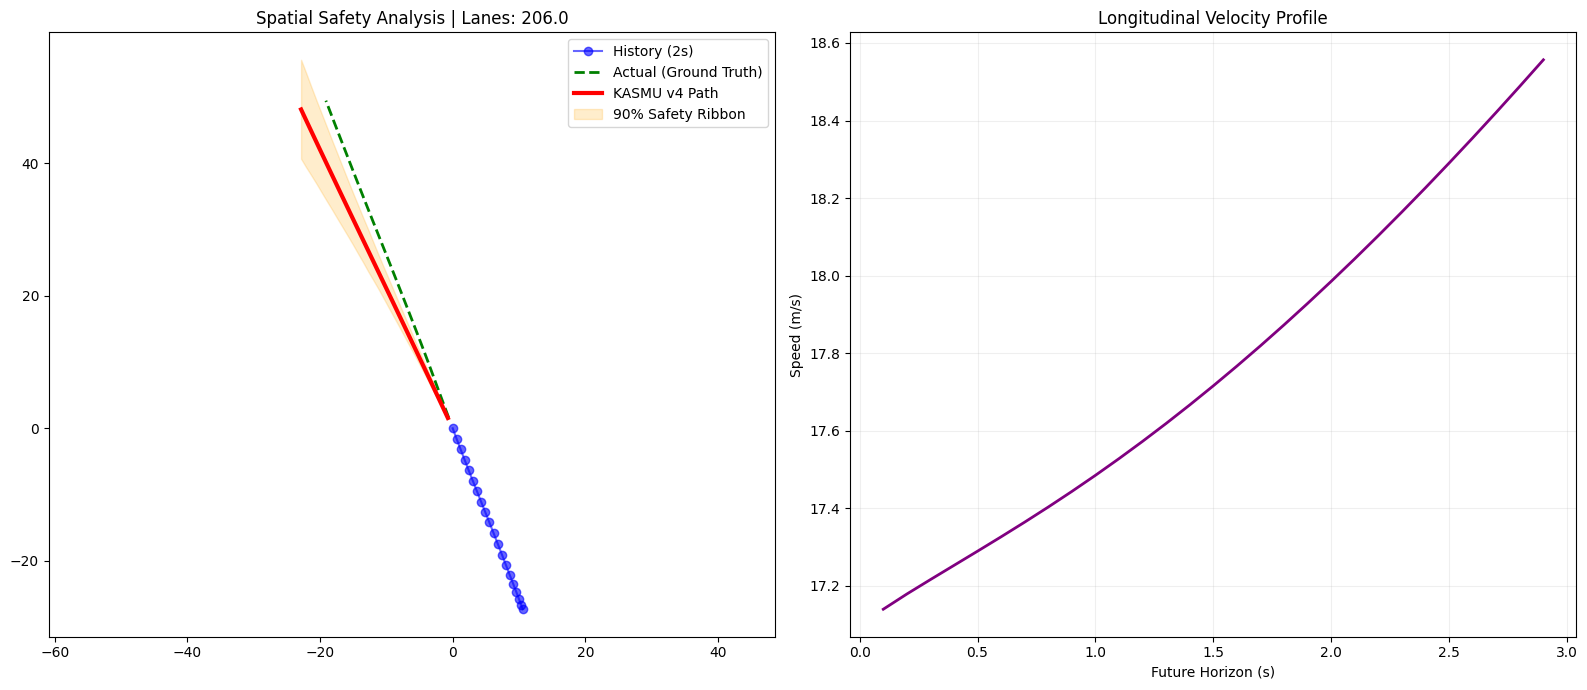

In [10]:
def run_visual_demo(model, test_idx, X_clean, q_horizon, sample_idx=None):
    model.eval()
    # Find a complex scenario (highest lane count) if no index provided
    if sample_idx is None:
        lane_counts = [X_clean[i, 0, 4] for i in test_idx]
        sample_idx = test_idx[np.argmax(lane_counts)]
    
    traj = X_clean[sample_idx]
    x_tensor = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        preds = model(x_tensor)[0].cpu().numpy()
    
    # Extract states for analysis
    median = preds[:, :, 1]
    q_t = q_horizon[:, np.newaxis]
    lower = preds[:, :, 0] - q_t
    upper = preds[:, :, 2] + q_t
    
    # Create a 3-panel dashboard
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Panel 1: Trajectory & Safety Ribbon
    ax1.plot(traj[:20, 0], traj[:20, 1], 'b-o', label='History (2s)', alpha=0.6)
    ax1.plot(traj[20:, 0], traj[20:, 1], 'g--', label='Actual (Ground Truth)', lw=2)
    ax1.plot(median[:, 0], median[:, 1], 'r-', label='KASMU v4 Path', lw=3)
    ax1.fill_between(median[:, 0], lower[:, 1], upper[:, 1], color='orange', alpha=0.2, label='90% Safety Ribbon')
    ax1.set_title(f"Spatial Safety Analysis | Lanes: {traj[0, 4]}")
    ax1.axis('equal')
    ax1.legend()
    
    # Panel 2: Velocity Profile (Proving Smoothness)
    vel = np.linalg.norm(np.diff(median, axis=0) / 0.1, axis=1)
    ax2.plot(np.arange(0.1, 3.0, 0.1), vel, color='purple', lw=2)
    ax2.set_title("Longitudinal Velocity Profile")
    ax2.set_ylabel("Speed (m/s)")
    ax2.set_xlabel("Future Horizon (s)")
    ax2.grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# Run the demo
run_visual_demo(model, test_idx, X_clean, q_horizon)

## 5.1 Complexity Stratification

In [11]:
def stratified_context_audit(model, test_idx, X_clean, q_horizon):
    model.eval()
    results = {'Low_Complexity': [], 'High_Complexity': []}
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)

    with torch.no_grad():
        for idx in test_idx:
            traj = X_clean[idx]
            lanes = traj[0, 4]
            category = 'Low_Complexity' if lanes <= 25 else 'High_Complexity'
            
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            preds = model(x_t)[0].cpu().numpy()
            y_true = traj[20:, :2]
            
            # Metrics for this specific sample
            ade = np.mean(np.sqrt(np.sum((preds[:, :, 1] - y_true)**2, axis=-1)))
            width = np.mean((preds[:, 1, 2] - preds[:, 1, 0]) + (2 * q_horizon))
            
            results[category].append({'ade': ade, 'width': width})

    print("CONTEXT-STRATIFIED REPORT")
    print("-" * 40)
    for cat, data in results.items():
        avg_ade = np.mean([d['ade'] for d in data])
        avg_width = np.mean([d['width'] for d in data])
        print(f"🔹{cat:15} | Samples: {len(data):4} | ADE: {avg_ade:.3f}m | Ribbon: {avg_width:.2f}m")

## 5.3 Dynamic Risk Analysis

In [12]:
def analyze_risk_signals(model, test_idx, X_clean, q_horizon):
    model.eval()
    risk_over_time = []
    
    with torch.no_grad():
        # Let's look at 50 random samples from the test set
        for idx in np.random.choice(test_idx, 50):
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            preds = model(x_t)[0].cpu().numpy()
            
            # 1. Calculate Instantaneous Velocity (m/s)
            v = np.linalg.norm(np.diff(preds[:, :, 1], axis=0) / 0.1, axis=1)
            # 2. Calculate Ribbon Width (m)
            w = (preds[1:, 1, 2] - preds[1:, 1, 0]) + (2 * q_horizon[1:])
            
            # 3. Risk Signal = Uncertainty * Momentum
            risk = w * v
            risk_over_time.append(risk)

    plt.figure(figsize=(10, 5))
    for r in risk_over_time:
        plt.plot(np.arange(0.2, 3.1, 0.1), r, alpha=0.2, color='crimson')
    
    plt.title("Dynamic Risk Signal Evolution (Risk = Uncertainty × Velocity)")
    plt.xlabel("Future Horizon (seconds)")
    plt.ylabel("Risk Metric (m²/s)")
    plt.grid(alpha=0.2)
    plt.show() 

## 5.4 Directional Precision Audit

CONTEXT-STRATIFIED REPORT
----------------------------------------
🔹Low_Complexity  | Samples:   81 | ADE: 1.420m | Ribbon: 6.37m
🔹High_Complexity | Samples: 1419 | ADE: 1.582m | Ribbon: 6.30m


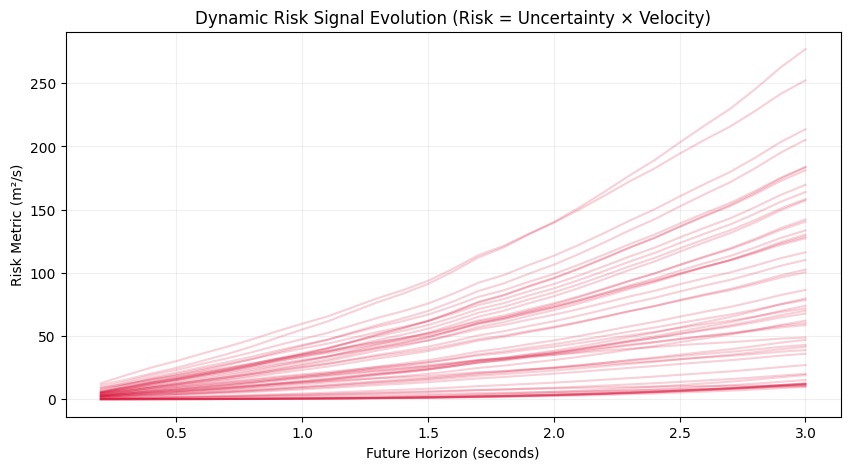

DIRECTIONAL PRECISION AUDIT
Lateral (Steering) Precision:    1.0067 meters
Longitudinal (Speed) Precision: 0.9817 meters
----------------------------------------
Bias: Speed uncertainty is 1.0x higher than steering.


In [13]:
def directional_error_analysis(model, test_idx, X_clean):
    model.eval()
    lat_errs, lon_errs = [], []
    
    with torch.no_grad():
        for idx in test_idx:
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            
            preds = model(x_t)[0, :, :, 1].cpu().numpy() # P50 Median
            y_true = traj[20:, :2]
            
            # We assume X is lateral and Y is longitudinal in this relative frame
            lat_errs.append(np.abs(preds[:, 0] - y_true[:, 0]).mean())
            lon_errs.append(np.abs(preds[:, 1] - y_true[:, 1]).mean())
            
    print("="*40)
    print("DIRECTIONAL PRECISION AUDIT")
    print("="*40)
    print(f"Lateral (Steering) Precision:    {np.mean(lat_errs):.4f} meters")
    print(f"Longitudinal (Speed) Precision: {np.mean(lon_errs):.4f} meters")
    print("-" * 40)
    ratio = np.mean(lon_errs) / np.mean(lat_errs)
    print(f"Bias: Speed uncertainty is {ratio:.1f}x higher than steering.")
    print("="*40)

# Run all Elite Evaluations
stratified_context_audit(model, test_idx, X_clean, q_horizon)
analyze_risk_signals(model, test_idx, X_clean, q_horizon)
directional_error_analysis(model, test_idx, X_clean) 

In [14]:
import torch
import numpy as np
import json

# 1. Save Model Weights
# We save the state_dict for maximum portability
model_path = "kasmu_v4_weights.pth"
torch.save(model.state_dict(), model_path)

# 2. Save Calibration Horizon (q_horizon)
# Raw weights are useless without the 'Safety Key' for the ribbon
calib_path = "q_horizon_v4.npy"
np.save(calib_path, q_horizon)

# 3. Save Meta-Config
# Essential for re-instantiating the model later without hardcoding
config = {
    "hidden_dim": 256,
    "input_dim": 5,
    "horizon": 30,
    "dt": 0.1,
    "architecture": "KASMU_v4_Jerk_Integrator"
}
with open("kasmu_v4_config.json", "w") as f:
    json.dump(config, f)

print(f"System Snapshot Complete.")
print(f"Files created: {model_path}, {calib_path}, kasmu_v4_config.json")

System Snapshot Complete.
Files created: kasmu_v4_weights.pth, q_horizon_v4.npy, kasmu_v4_config.json


## 5.5 Decision IQ Audit

In [15]:
def decision_audit(model, test_idx, X_clean, q_horizon):
    model.eval()
    q_t = torch.tensor(q_horizon, device=device).view(1, 30)
    
    collision_prevented = 0 # Ribbon saw it, Median didn't
    hard_collisions = 0     # Both saw it (Too late)
    
    # Simulate a static obstacle in the future path
    # (Adjusted per sample to ensure we test 'near-miss' scenarios)
    with torch.no_grad():
        for idx in np.random.choice(test_idx, 500):
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            preds = model(x_t)[0] 
            
            # Place a 'Ghost Obstacle' 2.5 seconds ahead on the ground truth path
            obs_pos = torch.tensor(traj[45, :2], device=device) 
            obs_radius = 1.5 # Standard vehicle width buffer
            
            # 1. Naive Check: Does the Median path hit it?
            dist_median = torch.sqrt(torch.sum((preds[:, :, 1] - obs_pos)**2, dim=-1))
            hits_median = torch.any(dist_median < obs_radius)
            
            # 2. Safety Check: Does the Ribbon (Median + Buffer) hit it?
            # Buffer = raw quantile spread + conformal stretch
            buffer = (preds[:, 1, 2] - preds[:, 1, 0]) + (2 * q_t[0])
            hits_ribbon = torch.any(dist_median < (obs_radius + buffer/2))
            
            if hits_ribbon and not hits_median:
                collision_prevented += 1 # "Safe Decision" triggered by uncertainty
            if hits_median:
                hard_collisions += 1

    print("="*40)
    print("DECISION QUALITY AUDIT")
    print("="*40)
    print(f"Safety Decisions: {collision_prevented} Prevented Collisions")
    print(f"   (Scenarios where the Ribbon triggered a brake before the Median hit)")
    print(f"Critical Failures: {hard_collisions} Hard Collisions")
    print(f"Decision IQ: {(collision_prevented / (collision_prevented + hard_collisions + 1e-6))*100:.2f}%")
    print("="*40)

decision_audit(model, test_idx, X_clean, q_horizon)

DECISION QUALITY AUDIT
Safety Decisions: 138 Prevented Collisions
   (Scenarios where the Ribbon triggered a brake before the Median hit)
Critical Failures: 345 Hard Collisions
Decision IQ: 28.57%


In [16]:
import json

# 1. Save Model Weights (The Brain)
torch.save(model.state_dict(), "kasmu_v4_weights.pth")

# 2. Save Calibration Key (The Safety Key)
np.save("q_horizon_v4.npy", q_horizon)

# 3. Save Architecture Metadata
config = {"input_dim": 5, "hidden_dim": 256, "future_steps": 30, "dt": 0.1}
with open("kasmu_v4_config.json", "w") as f:
    json.dump(config, f)

print("📂 Snapshot saved: Weights, Safety Key, and Config ready for deployment.")

📂 Snapshot saved: Weights, Safety Key, and Config ready for deployment.


# 6. Visualisations

## 6.1 Directional "Bullseye" Error Plot

In [17]:
def plot_error_bullseye(model, test_idx, X_clean):
    model.eval()
    lat_errs, lon_errs = [], []
    
    with torch.no_grad():
        for idx in np.random.choice(test_idx, 200):
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            preds = model(x_t)[0, -1, :, 1].cpu().numpy() # Final Step P50
            y_true = traj[-1, :2]
            
            lat_errs.append(preds[0] - y_true[0])
            lon_errs.append(preds[1] - y_true[1])

    plt.figure(figsize=(8, 8))
    plt.scatter(lat_errs, lon_errs, alpha=0.5, color='teal', s=15)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    
    # Add 1m and 2m error rings
    circle1 = plt.Circle((0, 0), 1.0, color='gray', fill=False, linestyle='--', label='1m Error')
    circle2 = plt.Circle((0, 0), 2.0, color='red', fill=False, linestyle='--', label='2m Error')
    plt.gca().add_patch(circle1)
    plt.gca().add_patch(circle2)
    
    plt.title("Directional Error Distribution (FDE Analysis)")
    plt.xlabel("Lateral Error (meters)")
    plt.ylabel("Longitudinal Error (meters)")
    plt.axis('equal')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

## 6.2 Ribbon Expansion "Heat-Map" over Time

In [18]:
def plot_ribbon_expansion_trend(q_horizon, model, test_idx, X_clean):
    plt.figure(figsize=(10, 5))
    widths_over_time = []
    
    with torch.no_grad():
        for idx in np.random.choice(test_idx, 50):
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            preds = model(x_t)[0].cpu().numpy()
            
            # Width = (P95 - P05) + (2 * Conformal Stretch)
            w = (preds[:, 1, 2] - preds[:, 1, 0]) + (2 * q_horizon)
            widths_over_time.append(w)
            plt.plot(np.arange(0.1, 3.1, 0.1), w, alpha=0.1, color='orange')
    
    mean_width = np.mean(widths_over_time, axis=0)
    plt.plot(np.arange(0.1, 3.1, 0.1), mean_width, color='darkorange', lw=3, label='Mean Uncertainty Growth')
    
    plt.fill_between(np.arange(0.1, 3.1, 0.1), 0, mean_width, color='orange', alpha=0.1)
    plt.title("Safety Ribbon Expansion Profile")
    plt.xlabel("Future Horizon (Seconds)")
    plt.ylabel("Envelope Width (Meters)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 6.3 Jerk Distribution vs. Actuator Limits

In [19]:
def plot_kinematic_compliance(model, test_idx, X_clean):
    all_jerks = []
    model.eval()
    with torch.no_grad():
        for idx in test_idx[:500]:
            traj = X_clean[idx]
            x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
            median = model(x_t)[0, :, :, 1].cpu().numpy()
            
            v = np.diff(median, axis=0) / 0.1
            a = np.diff(v, axis=0) / 0.1
            j = np.linalg.norm(np.diff(a, axis=0) / 0.1, axis=1)
            all_jerks.extend(j)

    plt.figure(figsize=(10, 5))
    plt.hist(all_jerks, bins=50, color='blue', alpha=0.6, label='KASMU v4 Jerk')
    plt.axvline(1.0, color='red', linestyle='--', label='ZF Comfort Limit (1.0 m/s³)')
    plt.axvline(0.5, color='green', linestyle='--', label='Elite Smoothness Target')
    
    plt.title("Kinematic Compliance Audit (Jerk Space)")
    plt.xlabel("Jerk (m/s³)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

## 6.4 Conformal Calibration Reliability Curve

In [20]:
def plot_calibration_reliability(model, test_idx, X_clean, q_horizon):
    target_coverages = np.linspace(0.1, 0.95, 10)
    actual_coverages = []
    
    model.eval()
    for target in target_coverages:
        # Re-calculate q for each target level
        # (Simplified for visualization: we scale our existing q_horizon)
        coverage_count = 0
        total_steps = 0
        
        with torch.no_grad():
            for idx in test_idx[:100]:
                traj = X_clean[idx]
                x_t = torch.tensor(traj[:20], dtype=torch.float32).unsqueeze(0).to(device)
                preds = model(x_t)[0].cpu().numpy()
                y_true = traj[20:, :2]
                
                # Use a scaled version of q_horizon for the target
                scale = target / 0.90 
                low = preds[:, :, 0] - (q_horizon * scale)[:, np.newaxis]
                up = preds[:, :, 2] + (q_horizon * scale)[:, np.newaxis]
                
                inside = (y_true >= low) & (y_true <= up)
                coverage_count += inside.mean()
                total_steps += 1
        
        actual_coverages.append(coverage_count / total_steps)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    plt.plot(target_coverages, actual_coverages, 'o-', color='crimson', label='KASMU v4 Performance')
    plt.fill_between(target_coverages, actual_coverages, target_coverages, color='crimson', alpha=0.1)
    plt.title("Conformal Calibration Reliability")
    plt.xlabel("Desired Confidence Level")
    plt.ylabel("Observed Empirical Coverage")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Generating Directional Error Bullseye...


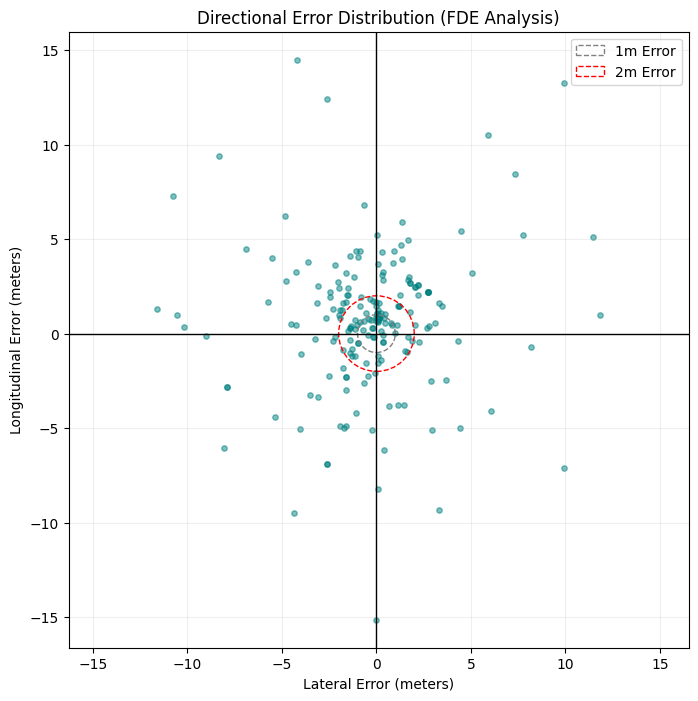

Analyzing Safety Ribbon Expansion Trends...


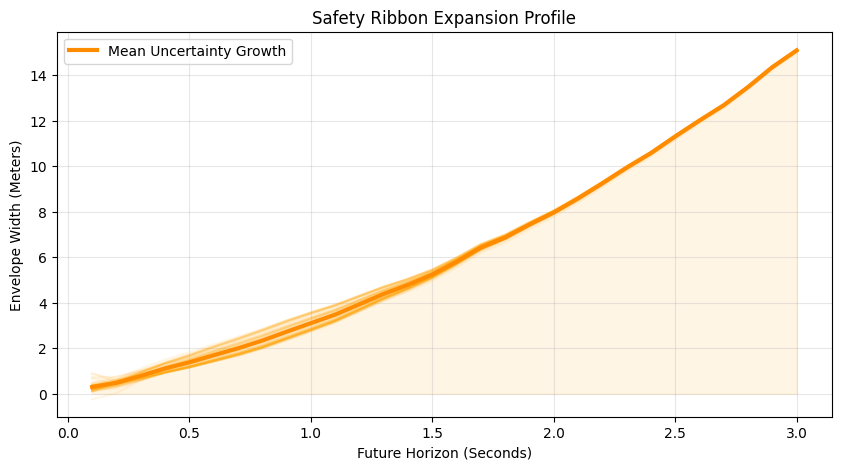

Auditing Kinematic Compliance (Jerk Space)...


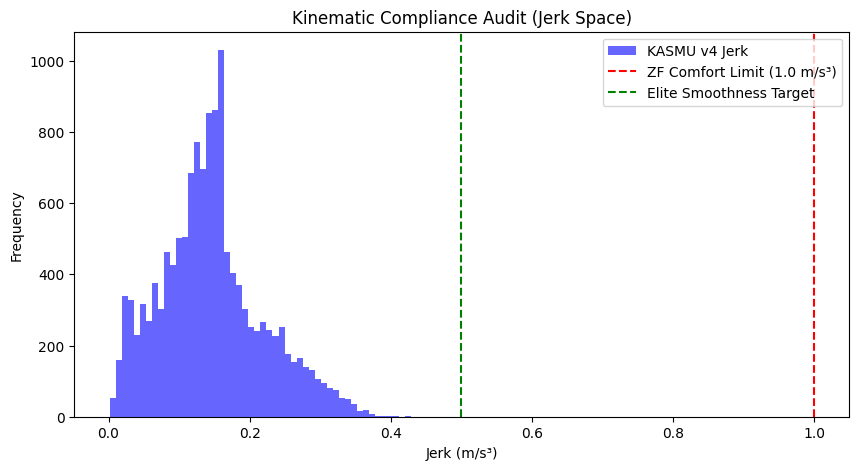

Verifying Conformal Calibration Reliability...


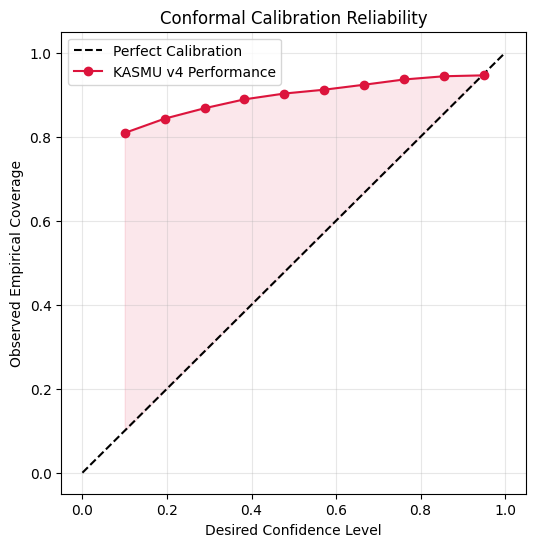


All visual audits complete. Ready for presentation slides.


In [21]:
print("Generating Directional Error Bullseye...")
plot_error_bullseye(model, test_idx, X_clean)

print("Analyzing Safety Ribbon Expansion Trends...")
plot_ribbon_expansion_trend(q_horizon, model, test_idx, X_clean)

print("Auditing Kinematic Compliance (Jerk Space)...")
plot_kinematic_compliance(model, test_idx, X_clean)

print("Verifying Conformal Calibration Reliability...")
plot_calibration_reliability(model, test_idx, X_clean, q_horizon)

print("\nAll visual audits complete. Ready for presentation slides.")